In [325]:
import taichi as ti
ti.init(arch=ti.gpu, default_fp=ti.f32)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import time

[Taichi] Starting on arch=cuda


Getting the data to compare to.

In [326]:
data = np.genfromtxt("sim_data.csv", delimiter=",", skip_header=True)
num_time_datapoints = data.shape[0]

var_1_range = (0, 2*ti.math.pi)
var_2_range = (0, 10)

Setting up the number of simulations happening at the same time, and for how long they should run.

In [327]:
num_sims = (800, 800)
sim_time = data[-1, 0] #in seconds, running the simulation for as long as the data goes

In [328]:
sims = ti.Vector.field(2, ti.float32, shape=num_sims)
costs = ti.field(ti.f32, shape=num_sims)

Helper Taichi functions

In [329]:
@ti.func
def map_range(value: float, min_in: float, max_in: float, min_out: float, max_out: float) -> float:
    return (value - min_in) / (max_in - min_in) * (max_out - min_out) + min_out

# a normal python version
def map_range_py(value: float, min_in: float, max_in: float, min_out: float, max_out: float) -> float:
    return (value - min_in) / (max_in - min_in) * (max_out - min_out) + min_out

Setting up initial conditions of the pendulums.

In [330]:
@ti.kernel
def setup():
    for i, j in sims:
        theta_0 = map_range(i, 0, num_sims[0], var_1_range[0], var_1_range[1])
        theta_d_0 = map_range(j, 0, num_sims[1], var_2_range[0], var_2_range[1])
        # theta_0 = np.pi - 0.1
        # theta_d_0 = 0.1

        sims[i, j] = ti.Vector([theta_0, theta_d_0])
        costs[i, j] = 0

Defining the function $f$ in $y' = f(y)$

In [331]:
# taichi versions

@ti.func
def get_angular_acceleration(y: ti.math.vec2, I: float, rcm: float, m: float, g: float) -> float:
    return -rcm*g*m*ti.sin(y[0])/I


@ti.func
def f(y: ti.math.vec2, I: float, rcm: float, m: float, g: float) -> ti.math.vec2:
    return ti.Vector([
        y[1],
        get_angular_acceleration(y, I, rcm, m, g)
    ])


# python versions

def get_angular_acceleration_py(y, I, rcm, m, g):
    return -rcm*g*m*np.sin(y[0])/I


def f_py(y, I, rcm, m, g):
    return np.array([
        y[1],
        get_angular_acceleration_py(y, I, rcm, m, g)
    ])

A simulation step.

In [332]:
h = 0.01  # simulation time increment


@ti.kernel
def update():

    # setting parameters kept constant, ones we are pretty sure of
    m = 1
    g = 9.81
    I = 1.92
    rcm = 1.2

    for i, j in sims:
        # setting parameters which change for each simulation
        # I = map_range(i, 0, num_sims[0], var_1_range[0], var_1_range[1])
        # rcm = map_range(j, 0, num_sims[1], var_2_range[0], var_2_range[1])

        oldValue = sims[i, j]
        k1 = h * f(oldValue, I, rcm, m, g)
        k2 = h * f(oldValue + k1/2, I, rcm, m, g)
        k3 = h * f(oldValue + k2/2, I, rcm, m, g)
        k4 = h * f(oldValue + k3, I, rcm, m, g)

        newValue = oldValue + k1/6 + k2/3 + k3/3 + k4/6
        sims[i, j] = newValue

Determining the $\chi^2$ contribution for this data point. This kernel runs when a data point lies between this simulation step and the next (in time). A RK4 step is then performed to get the simulation to the time at which the data point was recorded. Finally, the position at the end of the pivot is calculated for the data point and the simulated point, and their squared distances are divided by the data uncertainty and added to the running $\chi^2$ value. This is all done for each simulation simultaneously.

$\chi^2 = \sum^{N}_{i=1} \left[ \frac{y_i - f(x_i)}{\alpha_i}  \right]^2$

In [333]:
@ti.func
def get_chi_squared_term(prediction: ti.math.vec2, data: ti.math.vec2, data_error: ti.math.vec2) -> float:
    term_sqrt = (data - prediction) / data_error
    return ti.math.dot(term_sqrt, term_sqrt)


@ti.kernel
def add_cost(time_offset: float, data: ti.math.vec2, data_error: ti.math.vec2):
    # ! all of this needs to be identical to the values in update, except for time_offset instead of h

    # setting parameters kept constant, ones we are pretty sure of
    m = 1
    g = 9.81
    I = 1.92
    rcm = 1.2

    for i, j in sims:
        # setting parameters which change for each simulation
        # I = map_range(i, 0, num_sims[0], var_1_range[0], var_1_range[1])
        # rcm = map_range(j, 0, num_sims[1], var_2_range[0], var_2_range[1])

        oldValue = sims[i, j]
        k1 = time_offset * f(oldValue, I, rcm, m, g)
        k2 = time_offset * f(oldValue + k1/2, I, rcm, m, g)
        k3 = time_offset * f(oldValue + k2/2, I, rcm, m, g)
        k4 = time_offset * f(oldValue + k3, I, rcm, m, g)

        prediction = oldValue + k1/6 + k2/3 + k3/3 + k4/6

        # getting simulated position
        theta = prediction[0]
        x = 2*rcm*ti.math.sin(theta)
        y = -2*rcm*ti.math.cos(theta)

        thisCost = get_chi_squared_term(ti.Vector([x, y]), data, data_error)
        costs[i, j] += thisCost

Visualizing the result.

In [334]:
pixels = ti.Vector.field(3, ti.f32, shape=num_sims)


@ti.func
def colormap(val: float) -> ti.math.vec3:
    val = 1-val
    x = ti.max(0.0, ti.min(1.0, val))

    # A simplified Magma approximation
    r = 1.0 - ti.pow(1.0 - x, 3.0)
    g = ti.pow(x, 3.0) + 0.2 * ti.sin(3.14 * x)
    b = 0.2 + 0.6 * ti.pow(x, 5.0)

    return ti.Vector([ti.math.clamp(r, 0, 1),
                      ti.math.clamp(g, 0, 1),
                      ti.math.clamp(b, 0, 1)])


@ti.kernel
def draw(num_costs_calculated: int):
    for i, j in pixels:
        # pixels[i, j] = ti.Vector([sims[i, j][0], sims[i, j][1]/10 + 0.5, 0])
        costs_remapped = 0.14*ti.math.log(costs[i, j]/num_costs_calculated + 1)
        pixels[i, j] = colormap(costs_remapped)

Running the simulation loop.

In [335]:
window = ti.ui.Window("Visualization", (800, 800))
canvas = window.get_canvas()

t = 0
index_in_data = 0

setup()

for frame in range(int(sim_time/h)):
    if not window.running:
        break

    this_data_entry = data[index_in_data, :]
    next_cost_time = this_data_entry[0]

    # by next frame we will have jumped over the next data point, so now is the time to calculate the costs
    if (t <= next_cost_time and next_cost_time < t + h):
        add_cost(
            next_cost_time - t,
            ti.Vector([this_data_entry[1], this_data_entry[2]]),
            ti.Vector([this_data_entry[3], this_data_entry[4]])
        )
        index_in_data = index_in_data + 1
    t += h

    update()

    draw(index_in_data)
    if (t % (1/60)) < ((t - h) % (1/60)):
        canvas.set_image(pixels)
        window.show()
        # time.sleep(1/30)

window.destroy()

Now that we the grid of $\chi^2$ values, we need to find the element with the lowest $\chi^2$ and determine which parameters it represents.

In [336]:
costs_np = costs.to_numpy()
np.nan_to_num(costs_np, False, np.inf)
min_chi2 = np.min(costs_np)
min_indices = np.unravel_index(costs_np.argmin(), num_sims)

var_1_best = map_range_py(
    min_indices[0], 0, num_sims[0], var_1_range[0], var_1_range[1]
)
var_2_best = map_range_py(
    min_indices[1], 0, num_sims[1], var_2_range[0], var_2_range[1]
)

degrees_of_freedom = num_time_datapoints-2 #-2 because there are two parameters being fit
p_val = stats.chi2.sf(min_chi2, degrees_of_freedom)

print(
    "Variable 1: " + str(var_1_best), "Variable 2: " + str(var_2_best),
    "\nScore: " + str(min_chi2),
    "with " + str(degrees_of_freedom) + " degrees of freedom",
    "\np-value: " + str(p_val)
)

Variable 1: 3.0473448739820994 Variable 2: 0.075 
Score: 373.77417 with 298 degrees of freedom 
p-value: 0.0018612890128910653


Redoing this optimal simulation so that it can be viewed.

In [337]:
rcm_sim = 1.2
g_sim = 9.81
I_sim = 1/3 * (2*rcm_sim)**2
m_sim = 1

y = np.array([var_1_best, var_2_best])

h = 0.025
t = 0
sim_time = 10

past_positions = np.array([])
first = True

for i in range(int(sim_time/h)):
    k1 = h*f_py(y, I_sim, rcm_sim, m_sim, g_sim)
    k2 = h*f_py(y + k1/2, I_sim, rcm_sim, m_sim, g_sim)
    k3 = h*f_py(y + k2/2, I_sim, rcm_sim, m_sim, g_sim)
    k4 = h*f_py(y + k3, I_sim, rcm_sim, m_sim, g_sim)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    if (first):
        past_positions = np.array([y])
        first = False
    else:
        past_positions = np.vstack([past_positions, y])

theta_sim = past_positions[:, 0]
t_sim = np.arange(0, sim_time, h)
x_sim = 2*rcm_sim*np.sin(theta_sim)
y_sim = -2*rcm_sim*np.cos(theta_sim)

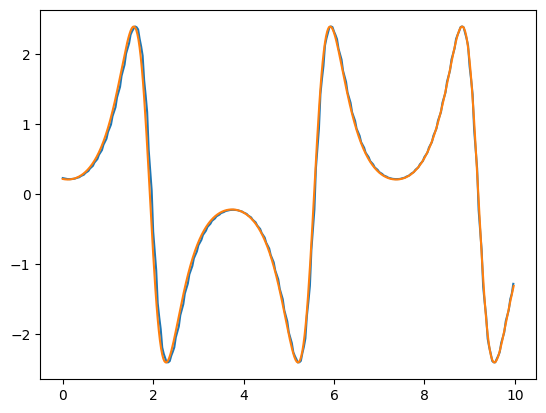

In [338]:
plt.plot(data[:, 0], data[:, 1])
plt.plot(t_sim, x_sim)